In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)

(2400, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB
None
(10009, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 

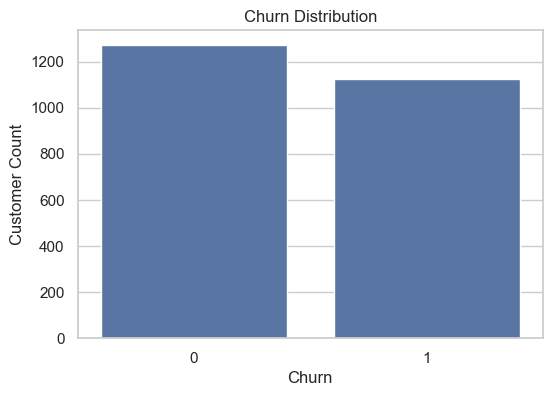

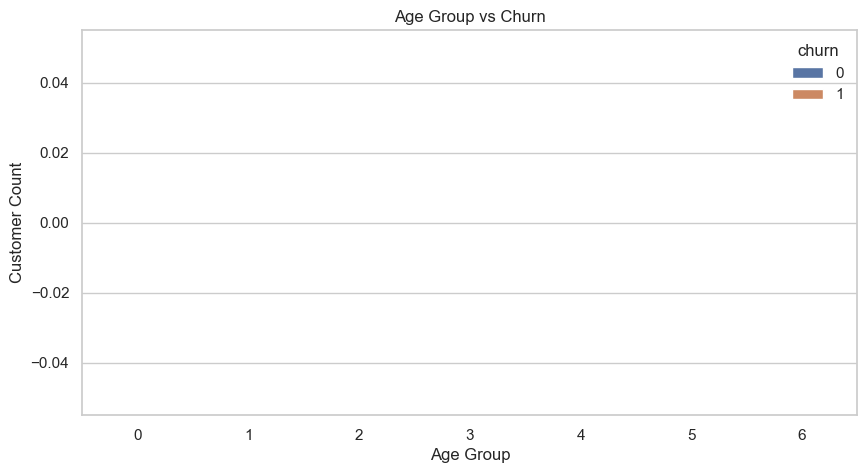

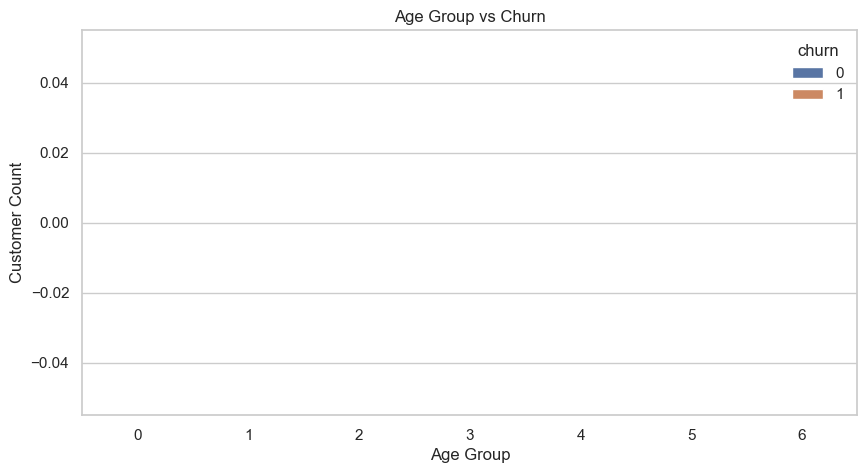

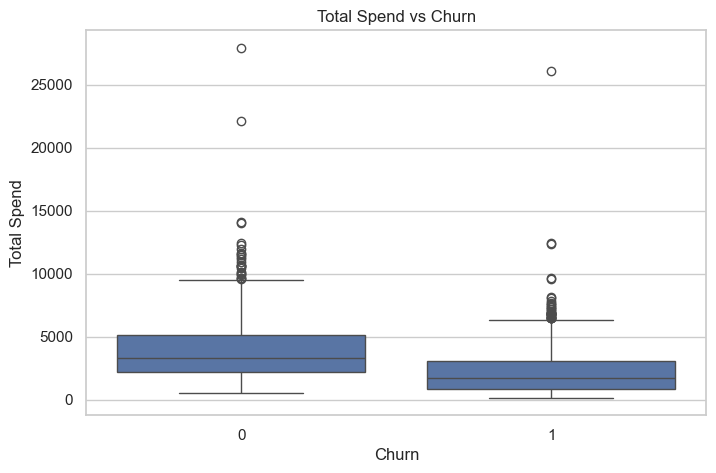

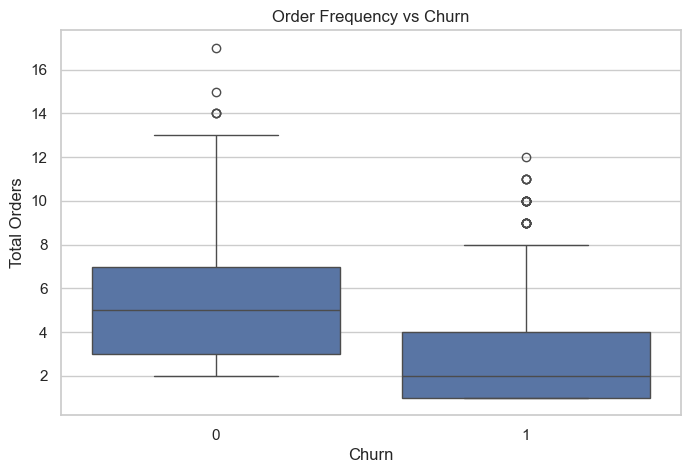

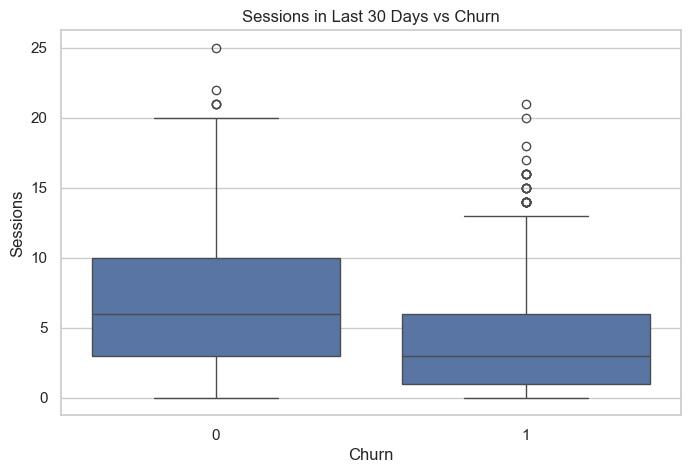

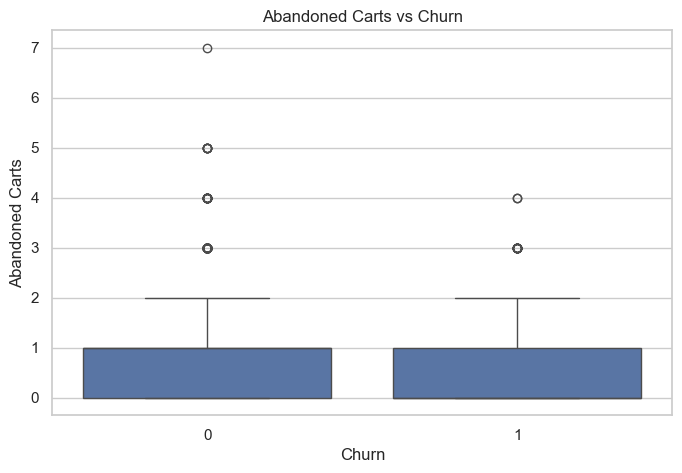

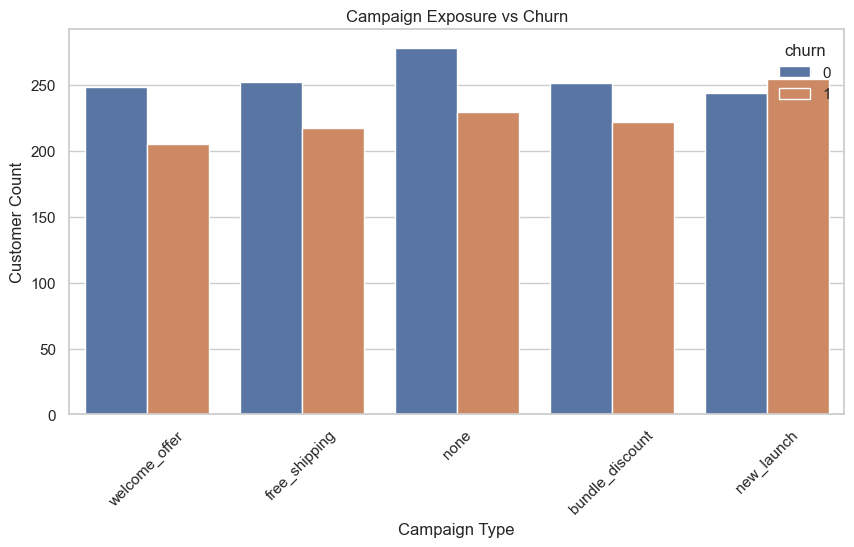

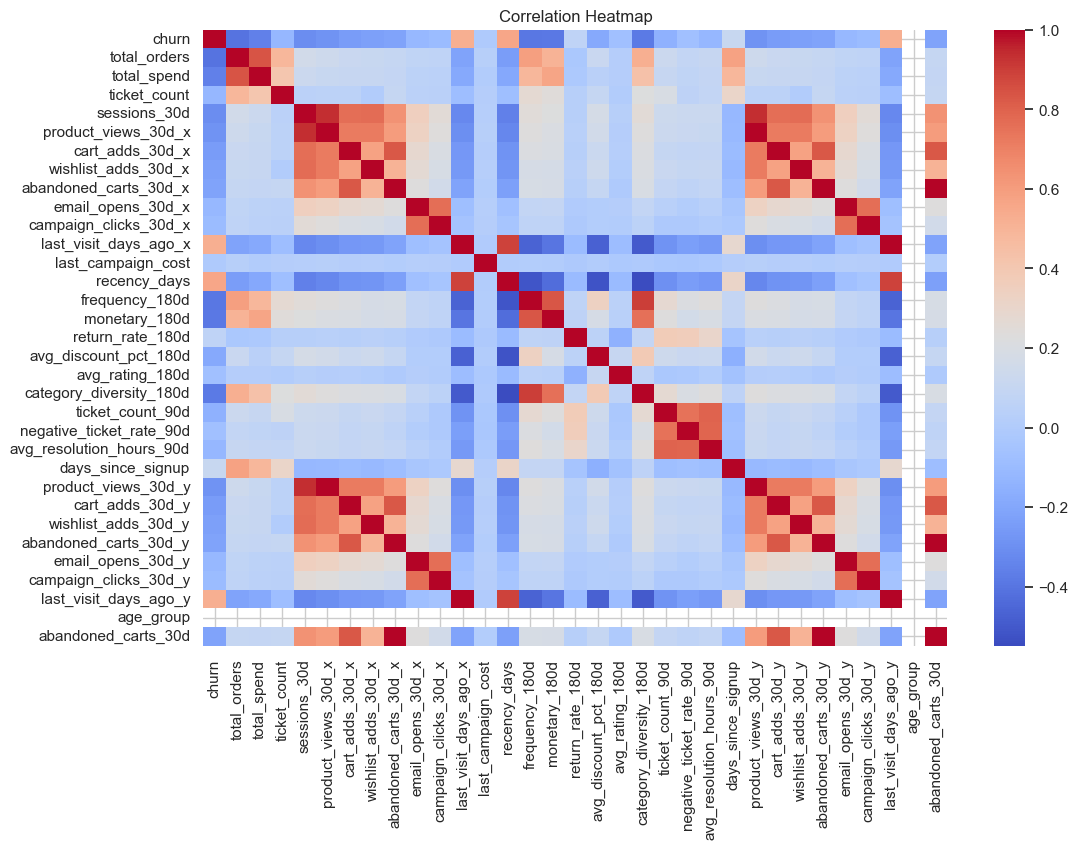

In [13]:
%run eda_audit.ipynb

In [3]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.6 MB/s eta 0:00:16
    --------------------------------------- 1.8/101.7 MB 4.4 MB/s eta 0:00:23
   - -------------------------------------- 2.9/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.7/101.7 MB 4.3 MB/s eta 0:00:23
   - -------------------------------------- 4.5/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 5.2/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 6.0/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 6.8/101.7 MB 4.1 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.1 MB/s eta 0:00:24
   --- ------------------------------------ 8.7/101.7 MB 4.0 MB/s eta 0:00:24



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------------------------ -- 524.3/555.9 kB 79.2 MB/s eta 0:00:01
   ---------------------------------------- 555.9/555.9 kB 1.9 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ---------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from xgboost import XGBClassifier
import shap

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries Loaded Successfully')

Libraries Loaded Successfully


In [15]:
df = pd.read_csv('rfm_modeling_snapshot.csv')

print('Dataset Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())

print('\nFirst 5 Rows:')
display(df.head())

Dataset Shape: (2400, 29)

Columns:
['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

First 5 Rows:


,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,362.73,0.0,0.23,3.0,1,0,0.0,0.0,524,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,581.00,0.0,0.23,4.0,1,1,0.0,1.0,121,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,649.98,0.0,0.47,2.0,1,0,0.0,0.0,206,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,1604.04,0.0,0.16,2.0,1,0,0.0,0.0,168,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,1781.90,0.0,0.48,1.0,2,0,0.0,0.0,405,18,95,4,1,1,3,1,9,0,train


In [16]:
print('=' * 60)
print('LEAKAGE CHECK')
print('=' * 60)

suspicious_cols = [
    c for c in df.columns
    if any(keyword in c.lower() for keyword in [
        'future',
        'next',
        'after',
        'post',
        'churn_date',
        'days_to_churn',
        'target_window',
        'future_orders'
    ])
]

print('\nPotential Leakage Columns:')
print(suspicious_cols)

churn_cols = [
    c for c in df.columns
    if 'churn' in c.lower() and c != 'churned'
]

print('\nChurn Related Columns:')
print(churn_cols)

print('\nOnly pre-snapshot information will be used.')

LEAKAGE CHECK

Potential Leakage Columns:
['churn_next_60d']

Churn Related Columns:
['churn_next_60d']

Only pre-snapshot information will be used.


In [18]:
print(df.columns.tolist())

['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']


In [19]:
TARGET = 'churn_next_60d'

In [20]:
DROP_COLUMNS = [
    'customer_id',
    'snapshot_date',
    TARGET
]

LEAKAGE_COLUMNS = suspicious_cols

ALL_DROP = DROP_COLUMNS + LEAKAGE_COLUMNS

X = df.drop(columns=ALL_DROP, errors='ignore')
y = df[TARGET]

print('Feature Shape:', X.shape)
print('Target Distribution:')
print(y.value_counts())

Feature Shape: (2400, 26)
Target Distribution:
churn_next_60d
0    1273
1    1127
Name: count, dtype: int64


In [28]:
if 'split' in df.columns:
    
    X_train = X[df['split'] == 'train']
    y_train = y[df['split'] == 'train']

    X_val = X[df['split'] == 'val']
    y_val = y[df['split'] == 'val']

    X_test = X[df['split'] == 'test']
    y_test = y[df['split'] == 'test']

    print('Using Provided Split Column')

else:

    X_temp, X_test, y_temp, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        stratify=y,
        random_state=42
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp,
        y_temp,
        test_size=0.176,
        stratify=y_temp,
        random_state=42
    )
    

Using Provided Split Column


In [29]:
Any object columns left?
[]

Object `left` not found.


[]

In [25]:
if 'split' in df.columns:

    X_train = X[df['split'] == 'train']
    y_train = y[df['split'] == 'train']

    X_val = X[df['split'] == 'val']
    y_val = y[df['split'] == 'val']

    X_test = X[df['split'] == 'test']
    y_test = y[df['split'] == 'test']

In [31]:
print(df['split'].value_counts())

split
train         1728
validation     336
test           336
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

# First split: train+val and test
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.176,
    stratify=y_temp,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

Train Shape: (1680, 26)
Validation Shape: (360, 26)
Test Shape: (360, 26)


In [33]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_ratio = negative / positive

print('Class Ratio:', scale_ratio)

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_ratio,
    min_child_weight=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=30,
    verbosity=0
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_val)
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

print('=' * 60)
print('XGBOOST MODEL')
print('=' * 60)

print(classification_report(
    y_val,
    xgb_preds,
    target_names=['Retained', 'Churned']
))

print('ROC-AUC:', roc_auc_score(y_val, xgb_probs))
print('PR-AUC :', average_precision_score(y_val, xgb_probs))

Class Ratio: 1.129277566539924
XGBOOST MODEL
              precision    recall  f1-score   support

    Retained       0.81      0.83      0.82       191
     Churned       0.80      0.79      0.79       169

    accuracy                           0.81       360
   macro avg       0.81      0.81      0.81       360
weighted avg       0.81      0.81      0.81       360

ROC-AUC: 0.8841971560457262
PR-AUC : 0.8486479125974417


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_val)
baseline_probs = baseline_model.predict_proba(X_val)[:, 1]

print('=' * 60)
print('BASELINE MODEL — LOGISTIC REGRESSION')
print('=' * 60)

print(classification_report(
    y_val,
    baseline_preds,
    target_names=['Retained', 'Churned']
))

print('ROC-AUC:', roc_auc_score(y_val, baseline_probs))
print('PR-AUC :', average_precision_score(y_val, baseline_probs))

BASELINE MODEL — LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.80      0.85      0.83       191
     Churned       0.82      0.76      0.79       169

    accuracy                           0.81       360
   macro avg       0.81      0.81      0.81       360
weighted avg       0.81      0.81      0.81       360

ROC-AUC: 0.882152483038508
PR-AUC : 0.8665193615529457


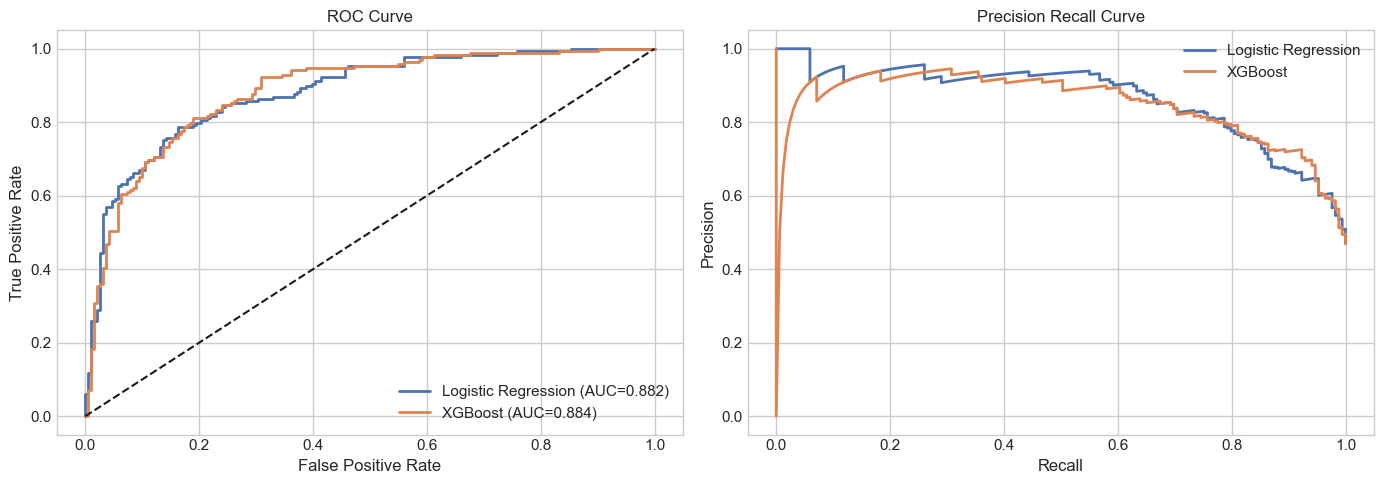

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for name, probs in [
    ('Logistic Regression', baseline_probs),
    ('XGBoost', xgb_probs)
]:

    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)

    axes[0].plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{name} (AUC={auc:.3f})'
    )

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# PR Curve
for name, probs in [
    ('Logistic Regression', baseline_probs),
    ('XGBoost', xgb_probs)
]:

    precision, recall, _ = precision_recall_curve(y_val, probs)

    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=name
    )

axes[1].set_title('Precision Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
thresholds = np.arange(0.10, 0.90, 0.05)

results = []

for threshold in thresholds:

    preds = (xgb_probs >= threshold).astype(int)

    report = classification_report(
        y_val,
        preds,
        output_dict=True,
        zero_division=0
    )

    results.append({
        'threshold': threshold,
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score']
    })

threshold_df = pd.DataFrame(results)

print(threshold_df)

best_row = threshold_df.sort_values(
    'f1',
    ascending=False
).iloc[0]

THRESHOLD = best_row['threshold']

print("\\nSelected Threshold:", THRESHOLD)

    threshold  precision    recall        f1
0        0.10   0.572414  0.982249  0.723312
1        0.15   0.626459  0.952663  0.755869
2        0.20   0.677966  0.946746  0.790123
3        0.25   0.696035  0.934911  0.797980
4        0.30   0.715596  0.923077  0.806202
5        0.35   0.730000  0.863905  0.791328
6        0.40   0.758065  0.834320  0.794366
7        0.45   0.787356  0.810651  0.798834
8        0.50   0.801205  0.786982  0.794030
9        0.55   0.824324  0.721893  0.769716
10       0.60   0.838028  0.704142  0.765273
11       0.65   0.856061  0.668639  0.750831
12       0.70   0.864000  0.639053  0.734694
13       0.75   0.879310  0.603550  0.715789
14       0.80   0.895238  0.556213  0.686131
15       0.85   0.908046  0.467456  0.617188
\nSelected Threshold: 0.30000000000000004


In [38]:
y_test_probs = xgb_model.predict_proba(X_test)[:, 1]

y_test_preds = (y_test_probs >= THRESHOLD).astype(int)

print(classification_report(
    y_test,
    y_test_preds,
    target_names=['Retained', 'Churned']
))

cm = confusion_matrix(y_test, y_test_preds)

print("\\nConfusion Matrix:")
print(cm)

print("\\nROC-AUC:", roc_auc_score(y_test, y_test_probs))
print("PR-AUC :", average_precision_score(y_test, y_test_probs))

              precision    recall  f1-score   support

    Retained       0.88      0.70      0.78       191
     Churned       0.73      0.89      0.80       169

    accuracy                           0.79       360
   macro avg       0.80      0.80      0.79       360
weighted avg       0.81      0.79      0.79       360

\nConfusion Matrix:
[[134  57]
 [ 18 151]]
\nROC-AUC: 0.8674370333653459
PR-AUC : 0.833071357812616


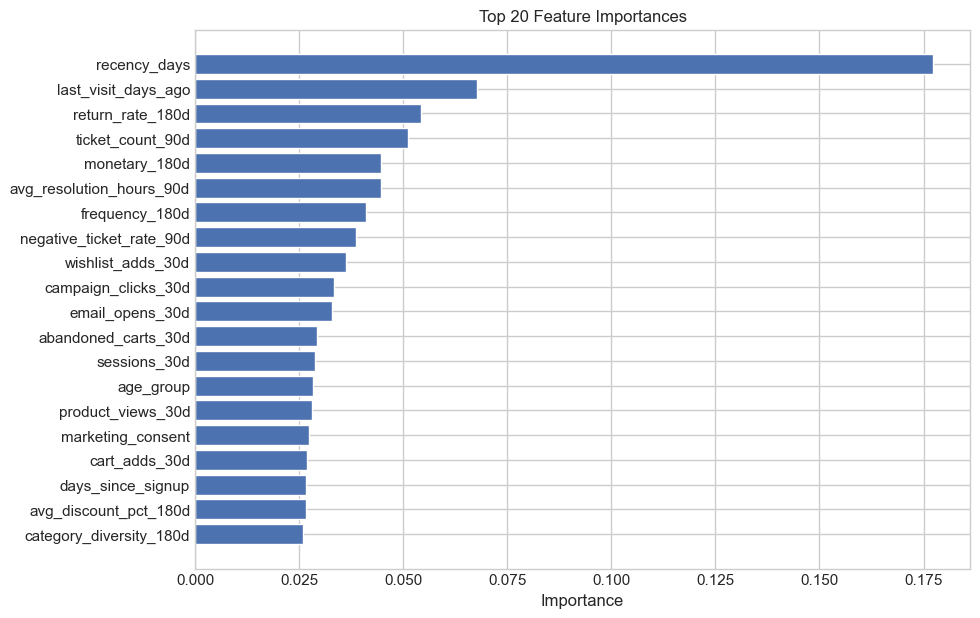

                     feature  importance
6               recency_days    0.177318
24       last_visit_days_ago    0.067815
9           return_rate_180d    0.054169
13          ticket_count_90d    0.051082
8              monetary_180d    0.044743
15  avg_resolution_hours_90d    0.044600
7             frequency_180d    0.041172
14  negative_ticket_rate_90d    0.038727
20         wishlist_adds_30d    0.036255
23       campaign_clicks_30d    0.033457


In [39]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))

plt.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1]
)

plt.title('Top 20 Feature Importances')
plt.xlabel('Importance')

plt.show()

print(importance_df.head(10))

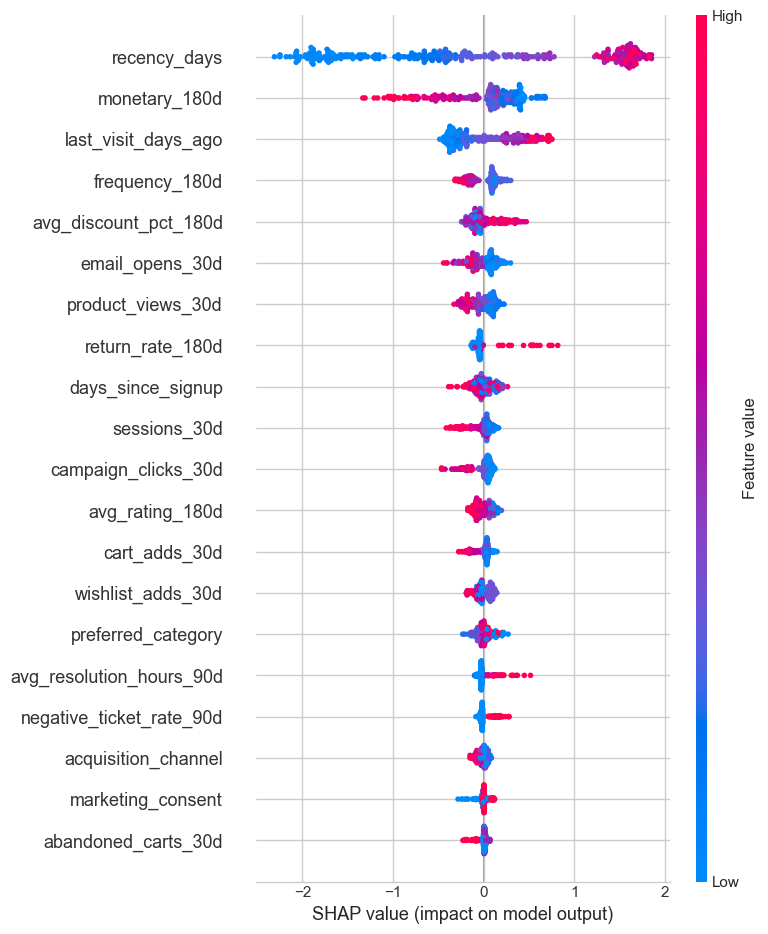

In [40]:
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test.iloc[:300]

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample
)

In [41]:
error_df = X_test.copy()

error_df['customer_id'] = df.loc[X_test.index, 'customer_id'].values
error_df['actual_churn'] = y_test.values
error_df['predicted_churn'] = y_test_preds
error_df['churn_probability'] = y_test_probs

# False Positives
FP = error_df[
    (error_df['predicted_churn'] == 1) &
    (error_df['actual_churn'] == 0)
]

# False Negatives
FN = error_df[
    (error_df['predicted_churn'] == 0) &
    (error_df['actual_churn'] == 1)
]

print("False Positives:", len(FP))
print("False Negatives:", len(FN))

print("\\nTop False Positives")
print(FP[['customer_id', 'churn_probability']].head())

print("\\nTop False Negatives")
print(FN[['customer_id', 'churn_probability']].head())

FP.head(10).to_csv('fp_examples.csv', index=False)
FN.head(10).to_csv('fn_examples.csv', index=False)

False Positives: 57
False Negatives: 18
\nTop False Positives
     customer_id  churn_probability
188    CUST00189           0.874467
1202   CUST01203           0.546109
939    CUST00940           0.910938
1028   CUST01029           0.715880
554    CUST00555           0.464988
\nTop False Negatives
     customer_id  churn_probability
615    CUST00616           0.245056
308    CUST00309           0.118060
1578   CUST01579           0.109696
866    CUST00867           0.242959
726    CUST00727           0.026936


In [42]:
joblib.dump(xgb_model, 'model.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [43]:
report = classification_report(
    y_test,
    y_test_preds,
    target_names=['Retained', 'Churned'],
    output_dict=True
)

metrics = {
    'accuracy': report['accuracy'],
    'precision': report['Churned']['precision'],
    'recall': report['Churned']['recall'],
    'f1_score': report['Churned']['f1-score'],
    'roc_auc': roc_auc_score(y_test, y_test_probs),
    'pr_auc': average_precision_score(y_test, y_test_probs),
    'threshold': float(THRESHOLD)
}

with open('metrics.json', 'w') as file:
    json.dump(metrics, file, indent=2)

print(metrics)

{'accuracy': 0.7916666666666666, 'precision': 0.7259615384615384, 'recall': 0.893491124260355, 'f1_score': 0.8010610079575596, 'roc_auc': 0.8674370333653459, 'pr_auc': 0.833071357812616, 'threshold': 0.30000000000000004}


In [44]:
FP.head()
FN.head()

,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,avg_rating_180d,category_diversity_180d,ticket_count_90d,negative_ticket_rate_90d,avg_resolution_hours_90d,days_since_signup,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,split,customer_id,actual_churn,predicted_churn,churn_probability
615,0,1,2,3,5,0,36,2,1139.91,0.00,0.165,4.0,2,1,1.0,8.3,326,10,41,4,1,1,0,0,16,1,CUST00616,1,0,0.245056
308,0,1,0,3,0,1,8,1,1014.02,0.00,0.350,3.0,1,0,0.0,0.0,573,13,43,2,4,1,8,1,12,1,CUST00309,1,0,0.118060
1578,0,0,3,2,3,1,45,5,4218.40,0.00,0.270,2.8,4,0,0.0,0.0,400,9,34,4,2,1,2,1,16,1,CUST01579,1,0,0.109696
866,1,1,5,3,4,0,15,1,424.64,0.00,0.550,5.0,1,1,1.0,1.0,20,6,21,3,1,1,0,0,22,1,CUST00867,1,0,0.242959
726,2,0,0,3,4,1,8,4,2696.01,0.25,0.343,4.0,2,0,0.0,0.0,447,10,40,3,1,1,6,2,7,2,CUST00727,1,0,0.026936
